<a href="https://colab.research.google.com/github/Nikoldbautista/Introduccion_ciencia_de_datos-/blob/main/Case_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1.Preparando nuestras herramientas y el Entorno de Negocio

Vamos a cargar las librerias estandar de Python y a generar un **Dataset Multivariable** de una empresa tecnologia multinacional

In [ ]:
#1. Pandas: Nuestro #Excel" con superadores de manuipulación
import pandas as pd #Importa Pandas

#2.Numpy: Motor de cálculos matemáticos de alto rendimineto
import numpy as np #Importa NumPy


#3. Matplotlib y Seaborn¨Para visualización cientifica anavanzada
import matplotlib.pyplot as plt #Importa Matplotlib
import seaborn as sns #Importa Seaborn

#Configuramos la estetica profesional para los graficos
sns.set_theme(style="whitegrid", palette="deep") #Define el estilo visual. whitegrid añade líneas de cuadrícula blancas y deep es la paleta de colores.
plt.rcParams["figure.figsize"] = (12, 6) #Establece el tamaño por defecto de todos los gráficos que se generen a 12 pulgadas de ancho por 6 de alto.

print("Herrameintas listas. Generando datos de la empresa 'TeachCorp'...")

#Generacion de un Dataset Multivaribale complejo (100 empeados)
np.random.seed(42) #fija una "semilla" aleatoria. Esto garantiza que, aunque los datos sean al azar, siempre obtengas los mismos resultados cada vez que corras el código.
n_empleados=1000 #Define una variable para crear 1,000 registros
df = pd.DataFrame({
    "ID_Empleado": range(1, n_empleados +1),# Aquí creo una columna con IDs únicos para cada empleado
    "Departamento": np.random.choice(["Ingenieria", "Ventas", "Marketing", "Directivos"], n_empleados, p=[0.5, 0.3, 0.15, 0.05]),# Aquí asigno a cada empleado un departamento de forma aleatoria, pero con probabilidades diferentes
    "Edad": np.random.normal(34, 8, n_empleados).astype(int),    # Aquí genero las edades con un promedio de 34 años y las convierto en números enteros
    "Años experiencia": np.random.normal(8, 4, n_empleados).clip(0, 40).astype(int),# Aquí genero los años de experiencia con promedio de 8, limito los valores entre 0 y 40 y los paso a enteros
    "Puntaje_Desempeño": np.random.normal(75, 12, n_empleados).clip(0,100).round(1) # Aquí creo un puntaje de desempeño, lo limito entre 0 y 100 y dejo solo un decimal
    })

#Salario base dependiendo del departamento
salarios_base = {"Ingenieria": 6000, "Ventas": 4000, "Marketing": 4500, "Directivos": 15000}
# Aquí calculo el salario total:
# tomo el salario base según el departamento
# le sumo dinero según los años de experiencia
# y agrego un poco de variación aleatoria para que sea más realista
df["Salario_USD"] = df["Departamento"].map(salarios_base) + (df["Años experiencia"] * 200) + np.random.normal(0, 500, n_empleados)

#Inyectamos Outliers reales (CEos con salarios exorbitantes)
outlier_idx = df[df["Departamento"] == "Directivos"].sample(5).index
df.loc[outlier_idx, "Salario_USD"] = [150000, 280000, 320000, 190000, 450000] # Aquí les cambio el salario por valores muy altos para simular casos extremos


df["Salario_USD"] = df["Salario_USD"].round(2)# Aquí redondeo los salarios a 2 decimales

print(df["Edad"][1])# Aquí muestro la edad de un empleado específico para verificar

display(df.head())# Aquí muestro las primeras filas para ver cómo quedó el dataset

print(f"\nDataset generado con {df.shape[0]} filas y {df.shape[1]} columnas.")# Aquí muestro cuántas filas y columnas tiene el dataset final

Herrameintas listas. Generando datos de la empresa 'TeachCorp'...
23


,ID_Empleado,Departamento,Edad,Años experiencia,Puntaje_Desempeño,Salario_USD
0,1,Ingenieria,35,2,85.5,6324.84
1,2,Directivos,23,7,67.2,16236.65
2,3,Ventas,37,1,60.6,3678.71
3,4,Ventas,38,11,62.5,5613.88
4,5,Ingenieria,38,8,69.2,7832.18



Dataset generado con 1000 filas y 6 columnas.


In [ ]:
df["Edad"] = df["Edad"].round(2)
# Aquí redondeo los valores de la columna 'Edad' a 2 decimales

print(df["Edad"][1])
# Aquí muestro la edad de un empleado específico para verificar

display(df.head())
# Aquí muestro las primeras filas del DataFrame para ver cómo quedó

print(f"\nDataset generado con {df.shape[0]} filas y {df.shape[1]} columnas.")
# Aquí muestro cuántas filas y columnas tiene el dataset final

23


,ID_Empleado,Departamento,Edad,Años experiencia,Puntaje_Desempeño,Salario_USD
0,1,Ingenieria,35,2,85.5,6324.84
1,2,Directivos,23,7,67.2,16236.65
2,3,Ventas,37,1,60.6,3678.71
3,4,Ventas,38,11,62.5,5613.88
4,5,Ingenieria,38,8,69.2,7832.18



Dataset generado con 1000 filas y 6 columnas.


##2. MEDIDAS DE TENDENCIA CENTRAL: Buscando el "Centro de Gravedad"

2.1 La media (Promedio Matematico)
**La analogia:** Imagina que el dataset es un tablero de madera y cada dato es una pesa. La media es el punto

In [ ]:
media_edad = df["Edad"].mean()
# Aquí calculo el promedio de la edad de todos los empleados

media_salario = df["Salario_USD"].mean()
# Aquí calculo el promedio de los salarios

print(f"La Edad promedio de la empresa es: {media_edad:.1f} años")
# Aquí muestro la edad promedio con 1 decimal

print(f"El Salario promedio (Media) es: ${media_salario:,.2f} USD")
# Aquí muestro el salario promedio con separador de miles y 2 decimales

La Edad promedio de la empresa es: 34.3 años
El Salario promedio (Media) es: $8,378.46 USD


2.2 la mediana y la trampa de los Outliers

**Pregunta para la clase:** ¿Es el salario promedio de $8,300 USD representativo de lo que gana un empleado normal de TeachCorp?

**La analogia:** Ordena a los 1,000 empleados en un pasillo larguisimo por orden de salario, Ve caminando hasta encontrar al empleado numero 500. Lo que el gane, esa es la **Mediana**. No le importa si el que esta de ultimo gnada 1 millon o 10 millones, la poscion del empleado 500 no cambia

EL EFECTO GRAVEDAD DE LOS MILLONARIOS
Media (Promedio Matematico): $8,378.46 USD
Mediana (El empleado del medio): $6,695.12 USD

¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.


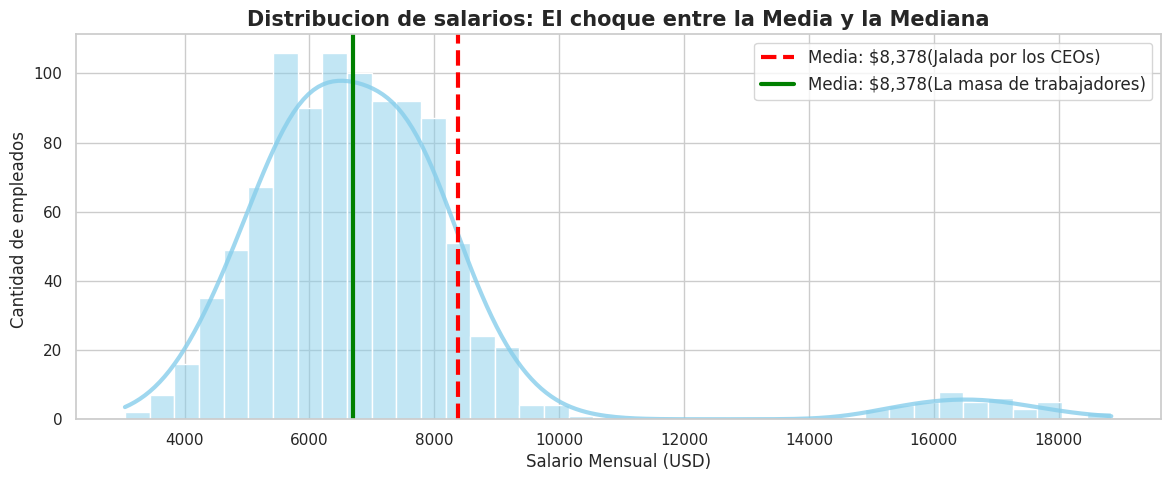

In [ ]:
#1. Calculos matematicos
media_salario = df["Salario_USD"].mean()
mediana_salario = df["Salario_USD"].median()

#Imprimimos la advertencia inicial
print("EL EFECTO GRAVEDAD DE LOS MILLONARIOS")
print(f"Media (Promedio Matematico): ${media_salario:,.2f} USD")
print(f"Mediana (El empleado del medio): ${mediana_salario:,.2f} USD")
print("\n¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.")

#2.Visualización Profesional: Impacto del Outlier con Envolante
plt.figure(figsize=(14, 5))

#TRUCO DE PROFESOR: Filtramos visualmente los datos menores a 35,000 para que la 'montaña' envolvente se dibuje correctamente y no se aplaste por la escala
datos_visuales = df[df["Salario_USD"] < 35000]

#Dibujamos el histograma y encenmos la envolvente con kde=True
sns.histplot(datos_visuales["Salario_USD"], bins=40, color="skyblue", kde=True, #kde=una curva d euna funcion
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8}) #Desracamos la envolvente en azul oscuro

#Dibujamos las lineas marcadoras (usando la media real con todos los outliers)
plt.axvline(media_salario, color="red", linestyle="dashed", linewidth= 3, label=f'Media: ${media_salario:,.0f}(Jalada por los CEOs)')
plt.axvline(mediana_salario, color="green", linestyle="solid", linewidth= 3, label=f'Media: ${media_salario:,.0f}(La masa de trabajadores)')

plt.title("Distribucion de salarios: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")
plt.xlabel("Salario Mensual (USD)")
plt.ylabel("Cantidad de empleados ")
plt.legend(fontsize=12)

EL EFECTO GRAVEDAD DE LOS MILLONARIOS
Media (Promedio Matematico): $8,378.46 USD
Mediana (El empleado del medio): $6,695.12 USD

¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.


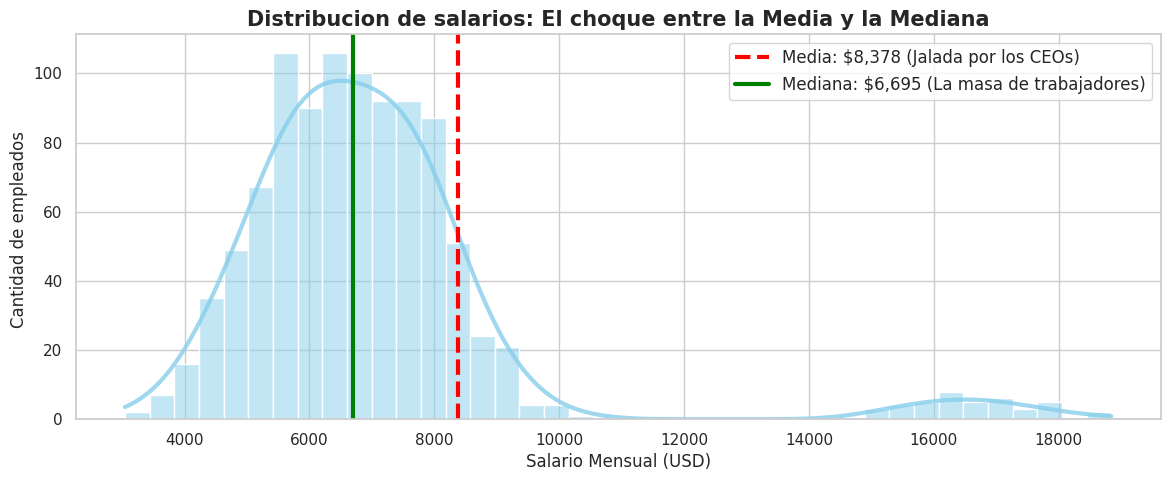

In [ ]:
#1. Calculos matematicos
media_salario = df["Salario_USD"].mean()
# Aquí calculo el promedio de los salarios

mediana_salario = df["Salario_USD"].median()
# Aquí calculo la mediana (el valor central de los salarios)

#Imprimimos la advertencia inicial
print("EL EFECTO GRAVEDAD DE LOS MILLONARIOS")
# Aquí muestro un título llamativo para explicar el análisis

print(f"Media (Promedio Matematico): ${media_salario:,.2f} USD")
# Aquí muestro el promedio de los salarios con formato bonito

print(f"Mediana (El empleado del medio): ${mediana_salario:,.2f} USD")
# Aquí muestro la mediana de los salarios

print("\n¿Notan la diferencia? ¡El promedio es engañoso! Parece que todos ganan casi 9 mil dolares.")
# Aquí explico que el promedio puede ser engañoso por los valores extremos

#2. Visualización Profesional: Impacto del Outlier con Envolvente
plt.figure(figsize=(14, 5))
# Aquí creo el espacio del gráfico con un tamaño más ancho

#TRUCO DE PROFESOR: Filtramos visualmente los datos menores a 35,000 para que la 'montaña' envolvente se dibuje bien
datos_visuales = df[df["Salario_USD"] < 35000]
# Aquí filtro los salarios menores a 35,000 para que el gráfico no se distorsione por los valores extremos

#Dibujamos el histograma y encendemos la envolvente con kde=True
sns.histplot(datos_visuales["Salario_USD"], bins=40, color="skyblue", kde=True,
             line_kws={"linewidth": 3, "color": "navy", "alpha": 0.8})
# Aquí hago el histograma con una curva suave encima (kde)
# también hago que la curva sea más gruesa, azul oscuro y un poco transparente

#Dibujamos las lineas marcadoras (usando la media real con todos los outliers)
plt.axvline(media_salario, color="red", linestyle="dashed", linewidth=3, label=f'Media: ${media_salario:,.0f} (Jalada por los CEOs)')
# Aquí dibujo la línea roja de la media, que está afectada por los salarios muy altos

plt.axvline(mediana_salario, color="green", linestyle="solid", linewidth=3, label=f'Mediana: ${mediana_salario:,.0f} (La masa de trabajadores)')
# Aquí dibujo la línea verde de la mediana, que representa mejor a la mayoría de empleados

plt.title("Distribucion de salarios: El choque entre la Media y la Mediana", fontsize=15, fontweight="bold")
# Aquí pongo el título del gráfico

plt.xlabel("Salario Mensual (USD)")
# Aquí nombro el eje X

plt.ylabel("Cantidad de empleados ")
# Aquí nombro el eje Y

plt.legend(fontsize=12)
# Aquí muestro la leyenda para identificar las líneas

##3. MEDIDAS DE VARIABLIDAD: Cuantificando el caos
El "Centro" es ciego a la estabilidad.

**- Deparatamento A:** Todos sacan 75 en su evaluacion de desempeño

**- Deparatamento B:** La mitad la saca 100 (genios) y la mitad saca 50 (pesimos). ¡Ambos tienen un promedio de 75! Pero el Depto B es una caos operativo

3.1 La desviacion estandar `std`

Nosindica, en promedio, que tan alejado esta cada empleado del centro generl

In [ ]:
# Comparamos la variabilidad del desempeño por departamento
dept_stats = df.groupby("Departamento")["Puntaje_Desempeño"].agg(["mean", "std"]).round(2)
# Aquí agrupo los datos por departamento y calculo el promedio (mean) y la desviación estándar (std) del desempeño
# luego redondeo los resultados a 2 decimales

dept_stats.columns = ["Media_Desempeño", "Desviacion_Estandar (Riesgo)"]
# Aquí cambio los nombres de las columnas para que sean más claros

display(dept_stats)
# Aquí muestro la tabla final con los resultados

,Media_Desempeño,Desviacion_Estandar (Riesgo)
Departamento,,
Directivos,75.67,11.93
Ingenieria,75.32,12.22
Marketing,74.19,12.55
Ventas,74.02,12.16


In [ ]:
# Comparamos la variabilidad de la edad por departamento
dept_stats = df.groupby("Departamento")["Edad"].agg(["mean", "std"]).round(2)
# Aquí agrupo los datos por departamento y calculo el promedio (mean) y la desviación estándar (std) de la edad
# uso agg para aplicar ambas funciones al mismo tiempo y redondeo a 2 decimales

dept_stats.columns = ["Media_Edad", "Desviacion_Estandar (Riesgo)"]
# Aquí cambio los nombres de las columnas para que se entiendan mejor

display(dept_stats)
# Aquí muestro la tabla con los resultados finales

,Media_Edad,Desviacion_Estandar (Riesgo)
Departamento,,
Directivos,33.28,7.49
Ingenieria,34.44,7.76
Marketing,33.81,8.41
Ventas,34.46,7.96


/tmp/ipykernel_187/3217224353.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Departamento", y="Puntaje_Desempeño", data=df, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos


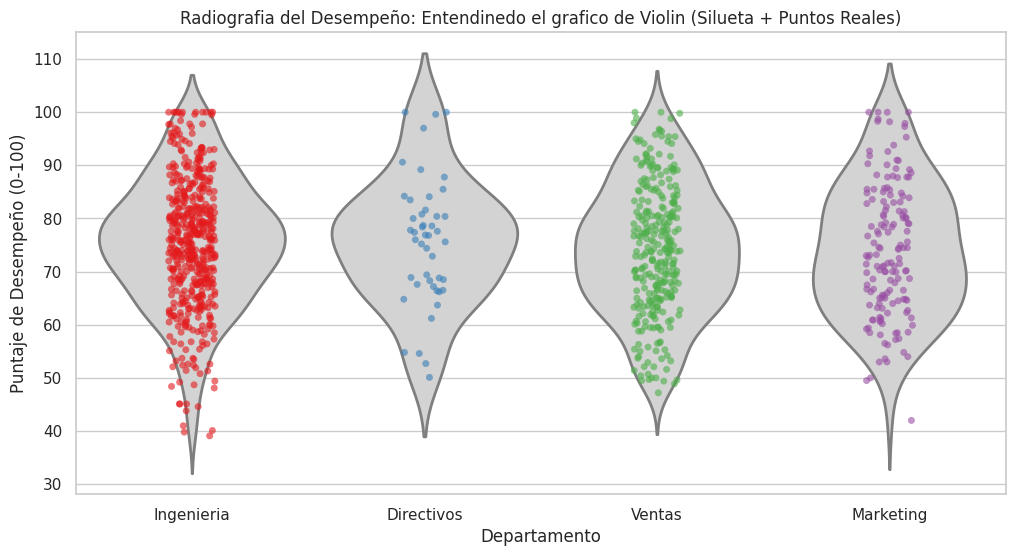

In [ ]:
#Visualización Didactica: Violin Plot revelado (Superponienod los puntos reales)
plt.figure(figsize=(12, 6))

#1. Dibujamos el violin "transparente" (La silueta)
sns.violinplot(x="Departamento", y="Puntaje_Desempeño", data=df, color="lightgray", inner=None, linewidth=2)#Pone los violines

#2. Superponemos a los empleados reales (los puntos de colores)
sns.stripplot(x="Departamento", y="Puntaje_Desempeño", data=df, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos

plt.title("Radiografia del Desempeño: Entendinedo el grafico de Violin (Silueta + Puntos Reales)")
plt.ylabel("Puntaje de Desempeño (0-100)")
plt.show()

Entre mas gordo sea el violin mas desviacion estandar, en ingenieria se maneja en porcenatjes e puntaje de desemepeño entonces ingenieria dtiene desde 39 hasta 100
Cada punto es un trabajador


/tmp/ipykernel_187/2613540604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Departamento", y="Edad", data=df, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos


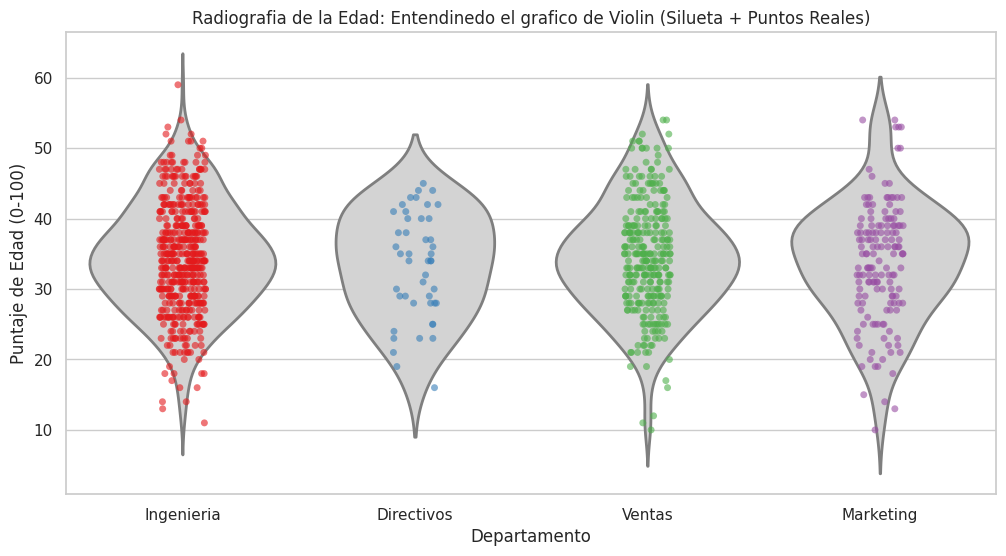

In [ ]:
#Visualización Didactica: Violin Plot revelado (Superponienod los puntos reales)
plt.figure(figsize=(12, 6))

#1. Dibujamos el violin "transparente" (La silueta)
sns.violinplot(x="Departamento", y="Edad", data=df, color="lightgray", inner=None, linewidth=2)#Pone los violines

#2. Superponemos a los empleados reales (los puntos de colores)
sns.stripplot(x="Departamento", y="Edad", data=df, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos

plt.title("Radiografia de la Edad: Entendinedo el grafico de Violin (Silueta + Puntos Reales)")
plt.ylabel("Puntaje de Edad (0-100)")
plt.show()

/tmp/ipykernel_187/3919463397.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="Departamento", y="Salario_USD", data=datos_visuales, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos


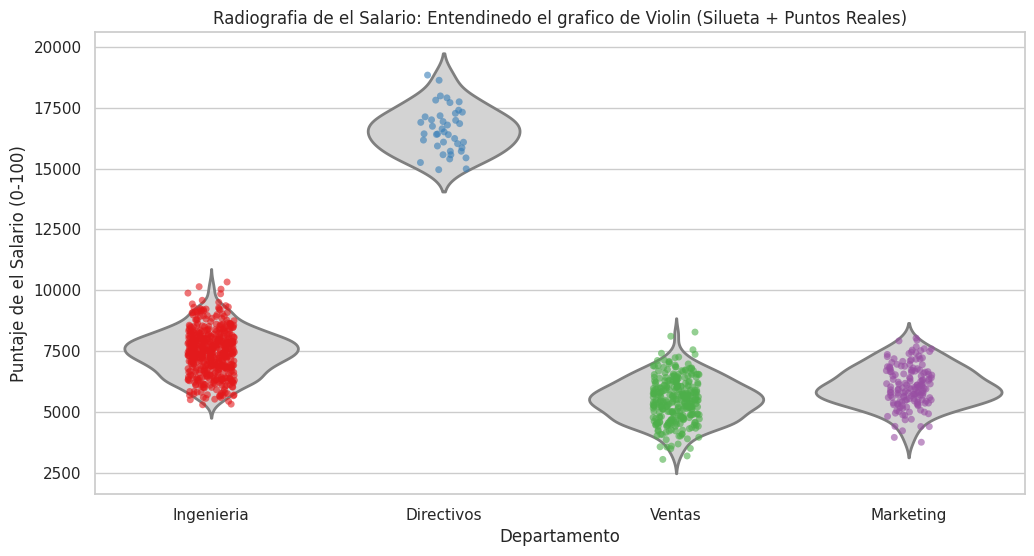

In [ ]:
datos_visuales = df[df["Salario_USD"] < 35000]

#Visualización Didactica: Violin Plot revelado (Superponienod los puntos reales)
plt.figure(figsize=(12, 6))

#1. Dibujamos el violin "transparente" (La silueta)
sns.violinplot(x="Departamento", y="Salario_USD", data=datos_visuales, color="lightgray", inner=None, linewidth=2)#Pone los violines

#2. Superponemos a los empleados reales (los puntos de colores)
sns.stripplot(x="Departamento", y="Salario_USD", data=datos_visuales, alpha=0.6, jitter=True, palette="Set1")#Pone los puntos

plt.title("Radiografia de el Salario: Entendinedo el grafico de Violin (Silueta + Puntos Reales)")
plt.ylabel("Puntaje de el Salario (0-100)")
plt.show()

In [ ]:
print("EXPLICACION VISUAL:")
print("-Cada punto de color es una persona (un empleado).")
print("-La sombra gris de fondo (el violin) es como una 'funda' que se adapta a donde esta la gente.")
print("-Si el violin es GORDO en el medio: Hay muchas gente amontonada ahi. Eso es baja variablidad")
print("-Si el violin es ALTO y DELGADO: La gemte esta muy dispersa. Eso significa alta desviacion Estandar")

#Variablidad (Dispersión): Indica ue tan alejados estan los datos entre si y respecto al valor central
#Desviacion Estandar: Es la raiz cuadrada de la varianza. Representa el promedio de las desviaciones de cada dato respecto a la media


EXPLICACION VISUAL:
-Cada punto de color es una persona (un empleado).
-La sombra gris de fondo (el violin) es como una 'funda' que se adapta a donde esta la gente.
-Si el violin es GORDO en el medio: Hay muchas gente amontonada ahi. Eso es baja variablidad
-Si el violin es ALTO y DELGADO: La gemte esta muy dispersa. Eso significa alta desviacion Estandar


##4. Medidas de posicion y la anatomia del Boxplot

¿Que pasa si quieres premiar al "Top 10%" de tus vendedores? Necesitas percentiles
4.1 La mate matica del Rango Intercuartilico (IQR)

Partimos nuestros datos en 4 tajadas de 25% (Cuartiles)

                                                    IQR=Q3-Q1
El IQR representa a la "masa critica", el 50% central de la poblacion. Es la herramienta principal para detectar fraudes y errores mediante la regla de los "Bigotes":


*   **Limite superior seguro:  
*   **Limite inferior seguro:

Cualquier dato fuera de estas fronteras matematicas, se declara oficilamente un **Outlier**.


--- RADIOGRAFIA DE LAS EDADES EN LA EMPRESA---
1. El Q1 (Inicio de la caja) es: 29 años. El 25% de la empresa es menor a esto
2. El Q3 (fin de la caja) es: 39 años. El 75% de la empresa es menor a esto
3. La masa principal (el IQR o tamaño de la caja) esta entre 29 y 39 años
4. ¡Alerta Outlier! segun la regla matematica, cualquier edad mayor a 54 años es atipica.

EXPLICACION:
- Vean como la caja verde empieza exactamente en la linea azul (Q1) y termina en la morada (Q3).
- El bigote derecho intenta llegar hasta el dato más lejano, pero se detiene en la 'pared roja' (límite superior).
- Cualquier punto que quede más allá de esa línea roja se considera un outlier.
------------------------------------------------------------


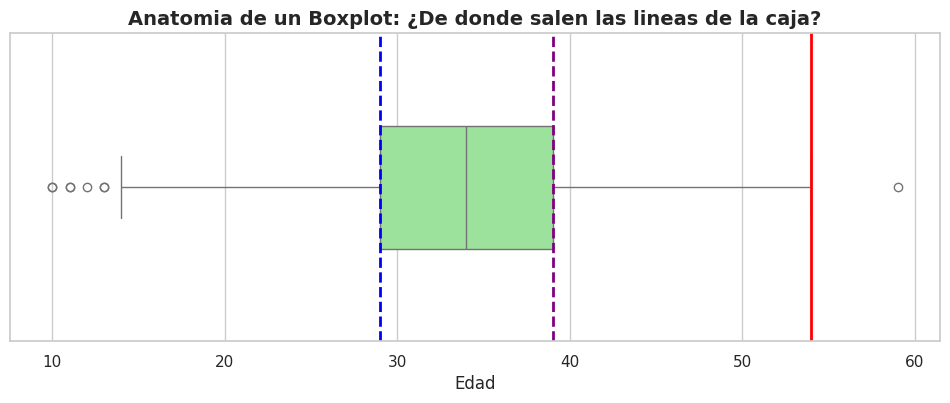

In [ ]:
#=========================================================================
# PARTE 1: LA ANATOMIA MATEMATICA Y VISUAL DEL BOXPLOT (Usando la edad)
#=========================================================================

#1. Calculamos matemáticamente paso a paso
Q1 = df['Edad'].quantile(0.25)
# Aquí calculo el primer cuartil (Q1), que es donde está el 25% de los datos

Mediana = df['Edad'].median()
# Aquí calculo la mediana, que es el valor central de las edades

Q3 = df['Edad'].quantile(0.75)
# Aquí calculo el tercer cuartil (Q3), donde está el 75% de los datos

IQR = Q3 - Q1
# Aquí calculo el rango intercuartílico (IQR), que es el tamaño de la caja del boxplot

limite_sup = Q3 + 1.5 * IQR
# Aquí calculo el límite superior para detectar outliers

limite_inf = Q1 - 1.5 * IQR
# Aquí calculo el límite inferior para detectar outliers

# Imprimimos el "guion" para la clase
print("--- RADIOGRAFIA DE LAS EDADES EN LA EMPRESA---")
# Aquí muestro un título para explicar el análisis

print(f"1. El Q1 (Inicio de la caja) es: {Q1:.0F} años. El 25% de la empresa es menor a esto")
# Aquí explico qué representa el Q1

print(f"2. El Q3 (fin de la caja) es: {Q3:.0F} años. El 75% de la empresa es menor a esto")
# Aquí explico qué representa el Q3

print(f"3. La masa principal (el IQR o tamaño de la caja) esta entre {Q1:.0F} y {Q3:.0F} años")
# Aquí explico el rango donde se concentra la mayoría de datos

print(f"4. ¡Alerta Outlier! segun la regla matematica, cualquier edad mayor a {limite_sup:.0f} años es atipica.\n")
# Aquí explico desde qué valor se consideran outliers

#2. Visualizacion Didactica: Dibujando las formulas
plt.figure(figsize=(12, 4))
# Aquí creo el espacio del gráfico

sns.boxplot(x=df['Edad'], color='lightgreen', width=0.4)
# Aquí dibujo el boxplot de las edades

# Trazamos líneas verticales para conectar los números con el dibujo
plt.axvline(Q1, color='blue', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f}) años')
# Aquí dibujo la línea del Q1

plt.axvline(Q3, color='purple', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f}) años')
# Aquí dibujo la línea del Q3

plt.axvline(limite_sup, color='red', linestyle='-', linewidth=2, label=f'Frontera Outliers Sup ({limite_sup:.0f} años)')
# Aquí dibujo la línea del límite superior de outliers

plt.title("Anatomia de un Boxplot: ¿De donde salen las lineas de la caja?", fontsize=14, fontweight='bold')
# Aquí pongo el título del gráfico

print("EXPLICACION:")
# Aquí empiezo una explicación tipo exposición

print("- Vean como la caja verde empieza exactamente en la linea azul (Q1) y termina en la morada (Q3).")
# Aquí explico visualmente la caja

print("- El bigote derecho intenta llegar hasta el dato más lejano, pero se detiene en la 'pared roja' (límite superior).")
# Aquí explico cómo funcionan los bigotes

print("- Cualquier punto que quede más allá de esa línea roja se considera un outlier.")
# Aquí explico qué son los outliers

print("-" * 60)
# Aquí hago una línea separadora para que se vea más ordenado

/tmp/ipykernel_187/1375132720.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Departamento", y="Edad", data=df, palette="Set1")#Pone los puntos


<Axes: xlabel='Departamento', ylabel='Edad'>

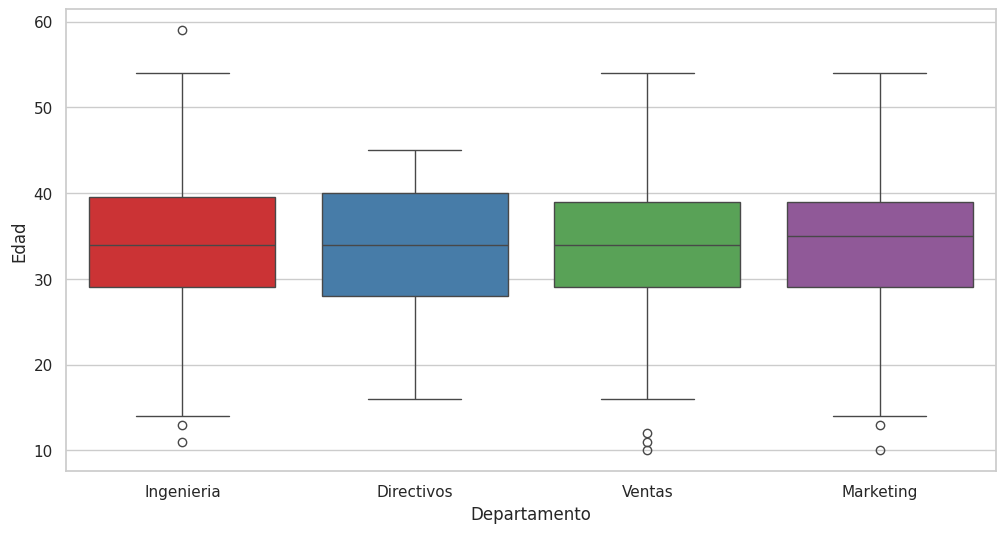

In [ ]:
sns.boxplot(x="Departamento", y="Edad", data=df, palette="Set1")#Pone los puntos

/tmp/ipykernel_187/252547506.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Departamento", y="Salario_USD", data=df, palette="Set1")#Pone los puntos


<Axes: xlabel='Departamento', ylabel='Salario_USD'>

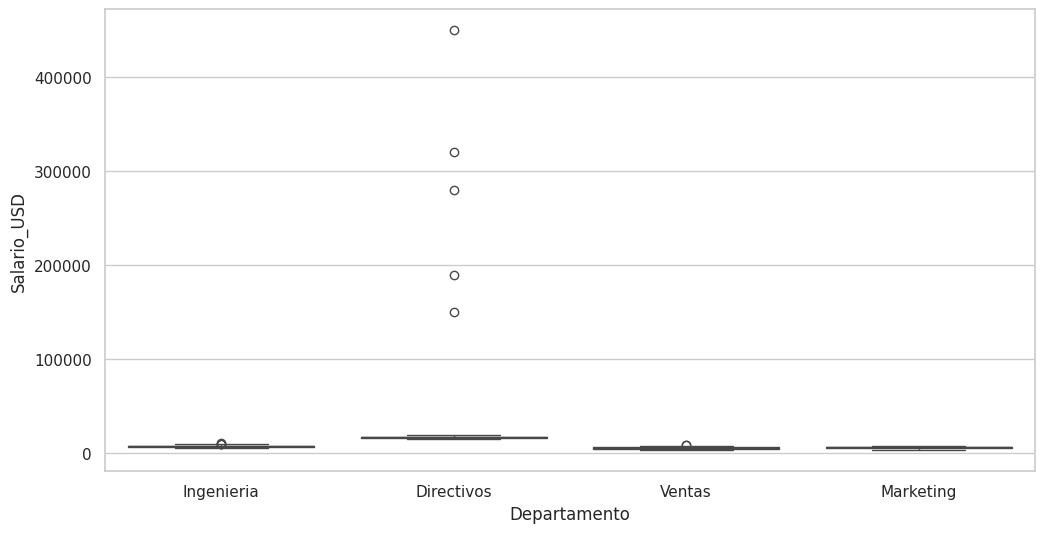

In [ ]:
sns.boxplot(x="Departamento", y="Salario_USD", data=df, palette="Set1")#Pone los puntos

/tmp/ipykernel_10299/2157137882.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Departamento", y="Puntaje_Desempeño", data=df, palette="Set1")


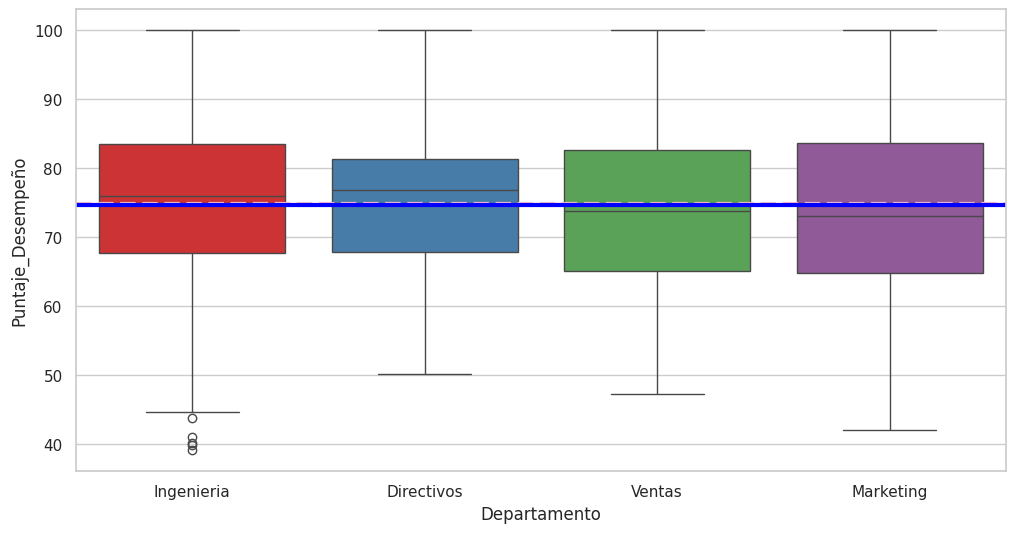

In [ ]:
sns.boxplot(x="Departamento", y="Puntaje_Desempeño", data=df, palette="Set1")
# Aquí hago un boxplot para comparar el puntaje de desempeño entre los diferentes departamentos
# uso colores del estilo "Set1" para que cada categoría se vea diferente

media_Edad = df["Puntaje_Desempeño"].mean()
# Aquí calculo el promedio del puntaje de desempeño

mediana_Edad = df["Puntaje_Desempeño"].median()
# Aquí calculo la mediana del puntaje de desempeño

plt.axhline(media_Edad, color="Pink", linestyle="dashed", linewidth=3, label='Media')
# Aquí dibujo una línea horizontal para mostrar el promedio (media)

plt.axhline(mediana_Edad, color="Blue", linestyle="solid", linewidth=3, label='Mediana')
# Aquí dibujo una línea horizontal para mostrar la medianadth= 3, label=f'Media')
